Generadores
===========

**Date:** 2023-11-07



## Ejemplo



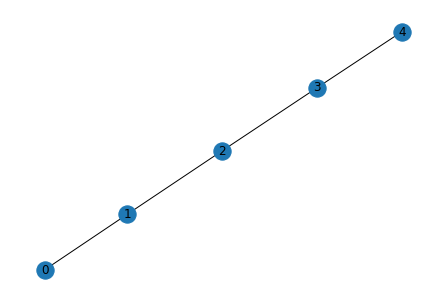

In [1]:
import networkx as nx
g = nx.path_graph(5)
nx.draw(g, with_labels=True)

In [2]:
clanes = nx.find_cliques(g)
clanes

<generator object find_cliques at 0x7f466cf15900>

In [7]:
next(clanes)

StopIteration: 

Cuando un generador se termina, ejecutar `next` produce la excepción `StopIteration`. Podemos entonces enlistar los clanes de la siguiente manera:



In [8]:
clanes = nx.find_cliques(g)

while True:
    try:
        clan = next(clanes)
        print(clan)
    except StopIteration:
        break

[1, 0]
[1, 2]
[3, 2]
[3, 4]


## Problema



Supongamos que queremos determinar si una gráfica muy grande tiene al menos un clan de tamaño al menos 10. (Con 1000 vértices se puede esperar un dibujo, con 10000 vértices ya toma demasiado tiempo)



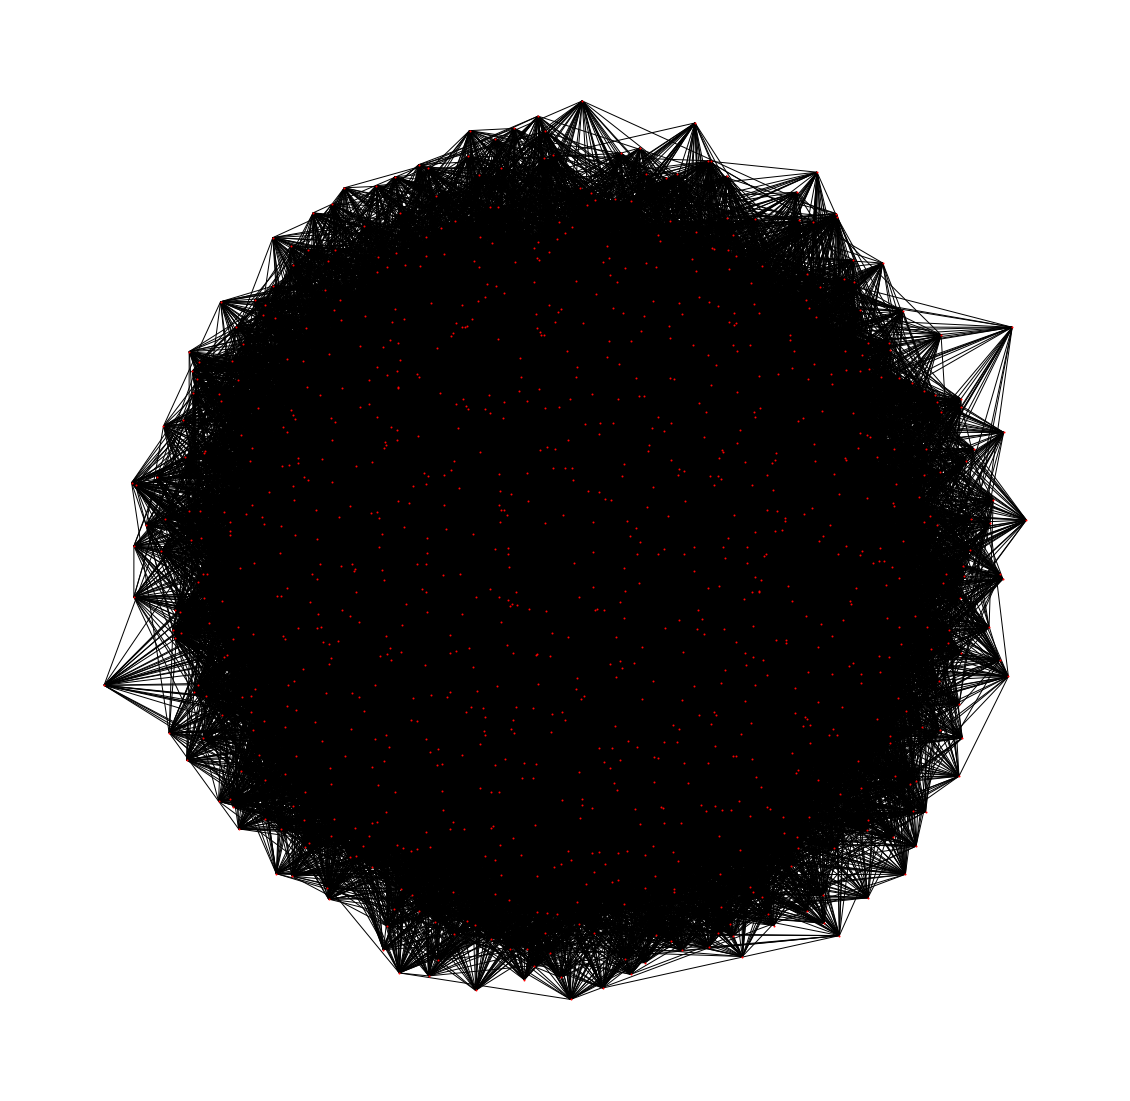

In [9]:
import networkx as nx
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(20, 20))

g = nx.gnp_random_graph(1000, 0.05)
nx.draw(g, node_size=1, node_color='red')

In [1]:
clanes = nx.find_cliques(g)
clanes

In [1]:
next(clanes)

In [1]:
len(list(clanes))

In [1]:
clanes = nx.find_cliques(g)

b = 6

for q in clanes:
    if len(q) >= b:
        print(f"El clan {q} tiene al menos {b} vértices")

In [1]:
b = 7

clanes = nx.find_cliques(g)

for q in clanes:
    if len(q) >= b:
        print(f"El clan {q} tiene al menos {b} vértices")
        break # Si encuentra el clan, 'break' interrumpe el ciclo 'for'
else: # una cláusula 'else' en un ciclo 'for' se ejecuta si el ciclo se agotó
    print("No encontré tal clan.")

## Definir generadores



Un generador se puede definir usando la misma sintaxis que para una función, pero usando la palabra `yield` en lugar de `return`. Cada llamada a `next` ejecuta la función hasta encontrar el siguiente `yield`.



In [10]:
def saludos():
    yield "Hola"
    yield "Qué tal"
    yield "Buenos días"

salu = saludos()
salu

<generator object saludos at 0x7f4655c06ba0>

In [13]:
next(salu)

'Buenos días'

In [14]:
def pares(m, n):
    for i in range(m):
        for j in range(n):
            yield (i, j)

gener = pares(3, 4)
gener

<generator object pares at 0x7f4655988040>

In [18]:
next(gener)

(0, 2)

In [19]:
gener2 = pares(3, 3)
list(gener2)

[(0, 0), (0, 1), (0, 2), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2)]

In [20]:
def cuadrados():
    i = 0
    while True:
        i = i+1
        yield i**2
    
cuads = cuadrados()
cuads

<generator object cuadrados at 0x7f4655988660>

In [25]:
next(cuads)

25

In [26]:
def fibo_gen():
    i, j = 0, 1
    while True:
        yield i
        i, j = i+j, i

fibos = fibo_gen()
fibos

<generator object fibo_gen at 0x7f4655988c10>

In [32]:
next(fibos)

5

También se puede obtener un generador por medio de una sintaxis parecida a la de las comprensiones de listas.



In [33]:
import networkx as nx

grafica = (nx.graph_atlas(i) for i in range(1253))
grafica

<generator object <genexpr> at 0x7f4655988b30>

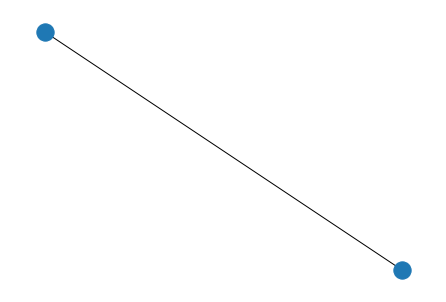

In [37]:
nx.draw(next(grafica))

## Leer archivos



Un archivo de texto se lee en Python por medio de un generador de sus líneas.



In [38]:
mis_datos = open("datos.csv")

In [43]:
linea=next(mis_datos)
linea

'lata,7,3\n'

In [44]:
linea.strip()

'lata,7,3'

## Tarea



Hacer una función que, dada una lista de cadenas, informe cuántas veces ocurre cada cadena. Por ejemplo, si la lista es `['la', 'casa', 'roja', 'es', 'roja']`, debe reportar que 'la', 'casa' y 'es' aparecen una vez cada una y 'roja' aparece dos veces.

Guardar la letra de una canción en un archivo de texto. Hacer una función que reciba el nombre del archivo y reporte cuántas veces ocurre cada palabra.

**Sugerencias** Para la primer tarea, escoger una estructura de datos que sea adecuada para el problema. Para la segunda, usar el método `strip` de una cadena, la cual remueve el carácter de salto de línea del final de una línea.



## Generación de objetos



Primero, veremos que los generadores pueden también tomar los objetos que generan a partir de un *iterador* utilizando el comando `yield from`:



In [62]:
def beatles():
    yield "John"
    yield from (x for x in ["Paul, George"])
    # yield from {"Paul":1, "George":0}
    # yield from ("Paul", "George")
    yield "Ringo"

b = beatles()    
# list(beatles())

In [63]:
for x in b:
    print(x)

John
Paul, George
Ringo


Esto nos puede servir para generar sucesiones de ceros y unos por medio de *backtracking*. La idea esencial del backtracking es construir un objeto (por ejemplo, un vector) poco a poco a través de sus componentes de manera recursiva.



In [86]:
def knapsack(l, X=()):
    if l == 5:
        yield X
    else:
        yield from knapsack(l+1, X+(2,))
        yield from knapsack(l+1, X+(1,))
        yield from knapsack(l+1, X+(0,))

gens = knapsack(0)        
list(gens)

[(2, 2, 2, 2, 2),
 (2, 2, 2, 2, 1),
 (2, 2, 2, 2, 0),
 (2, 2, 2, 1, 2),
 (2, 2, 2, 1, 1),
 (2, 2, 2, 1, 0),
 (2, 2, 2, 0, 2),
 (2, 2, 2, 0, 1),
 (2, 2, 2, 0, 0),
 (2, 2, 1, 2, 2),
 (2, 2, 1, 2, 1),
 (2, 2, 1, 2, 0),
 (2, 2, 1, 1, 2),
 (2, 2, 1, 1, 1),
 (2, 2, 1, 1, 0),
 (2, 2, 1, 0, 2),
 (2, 2, 1, 0, 1),
 (2, 2, 1, 0, 0),
 (2, 2, 0, 2, 2),
 (2, 2, 0, 2, 1),
 (2, 2, 0, 2, 0),
 (2, 2, 0, 1, 2),
 (2, 2, 0, 1, 1),
 (2, 2, 0, 1, 0),
 (2, 2, 0, 0, 2),
 (2, 2, 0, 0, 1),
 (2, 2, 0, 0, 0),
 (2, 1, 2, 2, 2),
 (2, 1, 2, 2, 1),
 (2, 1, 2, 2, 0),
 (2, 1, 2, 1, 2),
 (2, 1, 2, 1, 1),
 (2, 1, 2, 1, 0),
 (2, 1, 2, 0, 2),
 (2, 1, 2, 0, 1),
 (2, 1, 2, 0, 0),
 (2, 1, 1, 2, 2),
 (2, 1, 1, 2, 1),
 (2, 1, 1, 2, 0),
 (2, 1, 1, 1, 2),
 (2, 1, 1, 1, 1),
 (2, 1, 1, 1, 0),
 (2, 1, 1, 0, 2),
 (2, 1, 1, 0, 1),
 (2, 1, 1, 0, 0),
 (2, 1, 0, 2, 2),
 (2, 1, 0, 2, 1),
 (2, 1, 0, 2, 0),
 (2, 1, 0, 1, 2),
 (2, 1, 0, 1, 1),
 (2, 1, 0, 1, 0),
 (2, 1, 0, 0, 2),
 (2, 1, 0, 0, 1),
 (2, 1, 0, 0, 0),
 (2, 0, 2, 2, 2),
 (2, 0, 2,

In [88]:
def knapsack(l, X=()):
    if l == 2:
        yield X
    else:
        for x in [3, 2, 1, 0]:
            yield from knapsack(l+1, X+(x,))

gens = knapsack(0)        
list(gens)

[(3, 3),
 (3, 2),
 (3, 1),
 (3, 0),
 (2, 3),
 (2, 2),
 (2, 1),
 (2, 0),
 (1, 3),
 (1, 2),
 (1, 1),
 (1, 0),
 (0, 3),
 (0, 2),
 (0, 1),
 (0, 0)]

Podemos usar esta idea para generar tuplas de ceros y unos para resolver el problema Knapsack.



In [68]:
my_profits = (3, 5, 8, 2, 7, 4, 5, 6, 3, 3, 6)
my_weights = (1, 7, 5, 5, 6, 3, 2, 6, 2, 8, 2)

def my_knapsack(weights, profits, capacity):
    def _generate(l, X=()):
        if l == len(weights):
            yield X
        else:
            yield from _generate(l+1, X + (1,))
            yield from _generate(l+1, X + (0,))
   
    optP = 0
    optX = ()
    n = len(weights)
    for curX in _generate(0):
        if sum([weights[i]*curX[i] for i in range(n)]) <= capacity:
            curP = sum([profits[i]*curX[i] for i in range(n)])
            if curP > optP:
                optP = curP
                optX = curX
    return optP, optX
            
my_knapsack(my_weights, my_profits, 17)

(29, (1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1))

Sin embargo, esta función no sirve para poder aplicar el concepto de *podar* el árbol de búsqueda. En el siguiente código cada tupla se genera y se checa su factibilidad en una sola función.

Nótese que hemos tenido que introducir la instrucción `nonlocal` para que solo exista una copia de tales variables en cada recursión. Por un motivo parecido, hemos tenido que cargar con el parámetro `curX` en cada llamada recursiva.



In [72]:
my_profits = (3, 5, 8, 2, 7, 4, 5, 6, 1, 4, 6, 7, 10)
my_weights = (1, 7, 5, 5, 6, 3, 2, 6, 3, 3, 4, 3, 8)

def my_knapsack2(weights, profits, capacity):
    optP = 0
    optX = ()
    curP = 0
    n = len(weights)

    def _knapaux(l, curX):
        nonlocal optP, optX, curP
        if l == n:
            if sum([weights[i]*curX[i] for i in range(n)]) <= capacity:
                curP = sum([profits[i]*curX[i] for i in range(n)])
                if curP > optP:
                    optP = curP
                    optX = curX
        else:
            _knapaux(l+1, curX + (1,))
            _knapaux(l+1, curX + (0,))

    _knapaux(0, ())
    return optP, optX
            
my_knapsack2(my_weights, my_profits, 23)

(39, (1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1))

In [92]:
from random import randint

profits = tuple([randint(0, 10) for _ in range(28)])
weights = tuple([randint(0, 10) for _ in range(28)])
profits, weights

((3,
  2,
  8,
  1,
  2,
  1,
  6,
  5,
  3,
  0,
  8,
  7,
  5,
  8,
  3,
  8,
  4,
  4,
  1,
  5,
  7,
  9,
  2,
  2,
  0,
  4,
  10,
  9),
 (3,
  7,
  8,
  1,
  2,
  10,
  2,
  10,
  0,
  8,
  3,
  2,
  9,
  9,
  10,
  10,
  4,
  9,
  4,
  7,
  6,
  8,
  7,
  0,
  10,
  1,
  9,
  10))

In [85]:
%time my_knapsack2(weights, profits, 50)

CPU times: user 2min 17s, sys: 0 ns, total: 2min 17s
Wall time: 2min 17s


(79,
 (1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0))

Con esto, siguiendo el modelo del libro Kreher-Stinson, podemos mostrar el siguiente código que utiliza el concepto de podar el árbol de búsqueda (*pruning*).



In [89]:
my_profits = (3, 5, 8, 2, 7, 4, 5, 6, 1, 4, 6, 7, 10)
my_weights = (1, 7, 5, 5, 6, 3, 2, 6, 3, 3, 4, 3, 8)

def knapsack_pruning(weights, profits, capacity):
    optP = 0
    optX = ()
    curP = 0
    n = len(weights)
    Cl = []

    def _knapaux(l, curX, curW):
        nonlocal optP, optX, curP, Cl
        if l == n:
            if sum([profits[i]*curX[i] for i in range(n)]) > optP:
                optP = sum([profits[i]*curX[i] for i in range(n)])
                optX = curX
            Cl = []    
        else:
            if curW + weights[l] <= capacity:
                Cl = [1, 0]
            else:
                Cl = [0]
            for x in Cl:
                _knapaux(l+1, curX + (x,), curW + weights[l]*x)

    _knapaux(0, (), 0)
    return optP, optX
            
knapsack_pruning(my_weights, my_profits, 20)

(34, (1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0))

In [93]:
%time knapsack_pruning(weights, profits, 50)

CPU times: user 46.9 s, sys: 0 ns, total: 46.9 s
Wall time: 46.9 s


(74,
 (1,
  0,
  1,
  1,
  1,
  0,
  1,
  0,
  1,
  0,
  1,
  1,
  0,
  0,
  0,
  0,
  1,
  0,
  0,
  0,
  1,
  1,
  0,
  1,
  0,
  1,
  1,
  0))